In [30]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [31]:
df = pd.read_csv('paths.csv')
df.head(10)

,id,text,v_path,label
0,1,i didn't even want to go in there everyhere i ...,/kaggle/input/voice-dataset/1-W-ang.wav,ang
1,2,how can you speak so passionately about someth...,/kaggle/input/voice-dataset/2-W-ang.wav,ang
2,3,everything i have ever cared about is gone,/kaggle/input/voice-dataset/3-W-sad.wav,sad
3,4,i just want be a doctor or anything to help my...,/kaggle/input/voice-dataset/4-W-sad.wav,sad
4,5,i was pushing towards success and my mentor GP...,/kaggle/input/voice-dataset/5-W-happy.wav,hap
5,6,"dont judge me. i like rainbow, sparkles and un...",/kaggle/input/voice-dataset/6-W-happy.wav,hap
6,7,but i say you are executing his soul!,/kaggle/input/voice-dataset/7-W-ang.wav,ang
7,8,for all of gaza becouse they've been attacked ...,/kaggle/input/voice-dataset/8-W-sad.wav,sad
8,9,he broke up with me he dumped me for good,/kaggle/input/voice-dataset/9-W-sad.wav,sad
9,10,"Yeah, you want to see my supervisor? Huh? Yeah...",/kaggle/input/voice-dataset/10-W-ang.wav,ang


In [32]:
df = df.drop(columns=['v_path'])

word_replace = {
    'ang':'angry',
    'hap':'happy',
    'neu':'neutral'
}


df['label'] = df['label'].replace(word_replace, regex=True)

df.head()

,id,text,label
0,1,i didn't even want to go in there everyhere i ...,angry
1,2,how can you speak so passionately about someth...,angry
2,3,everything i have ever cared about is gone,sad
3,4,i just want be a doctor or anything to help my...,sad
4,5,i was pushing towards success and my mentor GP...,happy


In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
!pip install cleantext

In [35]:
import nltk

from nltk.tokenize import word_tokenize

from nltk.corpus import stopwords
# Download the stop words list
nltk.download('stopwords')
stop_words = stopwords.words('english')

from nltk.stem import WordNetLemmatizer
# Download the WordNet dictionary (for the lemmatizer)
nltk.download('wordnet')
lmt = WordNetLemmatizer()

from cleantext import clean
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [36]:
def transform(txt):
  txt = clean(txt, lowercase=True, punct=True)
  txt = word_tokenize(txt)
  return txt

In [37]:
transform('Hello !!! this is the KING of the world, Ashura...')

['hello', 'this', 'is', 'the', 'king', 'of', 'the', 'world', 'ashura']

In [38]:
df['transformed'] = df['text'].apply(transform)
df.head(10)

,id,text,label,transformed
0,1,i didn't even want to go in there everyhere i ...,angry,"[i, didnt, even, want, to, go, in, there, ever..."
1,2,how can you speak so passionately about someth...,angry,"[how, can, you, speak, so, passionately, about..."
2,3,everything i have ever cared about is gone,sad,"[everything, i, have, ever, cared, about, is, ..."
3,4,i just want be a doctor or anything to help my...,sad,"[i, just, want, be, a, doctor, or, anything, t..."
4,5,i was pushing towards success and my mentor GP...,happy,"[i, was, pushing, towards, success, and, my, m..."
5,6,"dont judge me. i like rainbow, sparkles and un...",happy,"[dont, judge, me, i, like, rainbow, sparkles, ..."
6,7,but i say you are executing his soul!,angry,"[but, i, say, you, are, executing, his, soul]"
7,8,for all of gaza becouse they've been attacked ...,sad,"[for, all, of, gaza, becouse, theyve, been, at..."
8,9,he broke up with me he dumped me for good,sad,"[he, broke, up, with, me, he, dumped, me, for,..."
9,10,"Yeah, you want to see my supervisor? Huh? Yeah...",angry,"[yeah, you, want, to, see, my, supervisor, huh..."


## Using CBOW

In [39]:
!pip install gensim

In [40]:
from gensim.models import Word2Vec

In [41]:
model = Word2Vec(
    sentences=df['transformed'].tolist(),
    sg=0,             # using CBOW [EVEN IF YOU DONT MENTION sg=0, word2vec WILL AUTOMATICALLY TAKE THE CBOW AS THE DEFAULT MODEL]
    vector_size=300,
    window=7,
    min_count=1,
    workers=4
)


print(f"LENGTH OF THE VOCABULARY : {len(model.wv.index_to_key)}")

LENGTH OF THE VOCABULARY : 370


In [42]:
df['transformed'].tolist()

[['i',
  'didnt',
  'even',
  'want',
  'to',
  'go',
  'in',
  'there',
  'everyhere',
  'i',
  'go',
  'people',
  'look',
  'at',
  'me',
  'like',
  'im',
  'a',
  'criminal'],
 ['how',
  'can',
  'you',
  'speak',
  'so',
  'passionately',
  'about',
  'something',
  'you',
  'wasnt',
  'there',
  'to',
  'witness'],
 ['everything', 'i', 'have', 'ever', 'cared', 'about', 'is', 'gone'],
 ['i',
  'just',
  'want',
  'be',
  'a',
  'doctor',
  'or',
  'anything',
  'to',
  'help',
  'my',
  'people',
  'but',
  'i',
  'cant',
  'im',
  'just',
  'a',
  'kid'],
 ['i',
  'was',
  'pushing',
  'towards',
  'success',
  'and',
  'my',
  'mentor',
  'gps',
  'announced',
  'youve',
  'arrived',
  'and',
  'i',
  'was',
  'like',
  'i',
  'know',
  'right'],
 ['dont',
  'judge',
  'me',
  'i',
  'like',
  'rainbow',
  'sparkles',
  'and',
  'unicorns',
  'im',
  'that',
  'kind',
  'of',
  'girl'],
 ['but', 'i', 'say', 'you', 'are', 'executing', 'his', 'soul'],
 ['for',
  'all',
  'of',
  

In [43]:
model.wv.most_similar('good')

[('state', 0.15905988216400146),
 ('corporal', 0.14976030588150024),
 ('the', 0.14781472086906433),
 ('just', 0.14390042424201965),
 ('his', 0.13541674613952637),
 ('father', 0.12878860533237457),
 ('kid', 0.12339093536138535),
 ('closest', 0.12154713273048401),
 ('back', 0.12077034264802933),
 ('dawson', 0.11946745216846466)]

In [44]:
model.wv.index_to_key     # will print all the words used in Word2Vec

['i',
 'you',
 'to',
 'the',
 'a',
 'and',
 'have',
 'of',
 'my',
 'he',
 'im',
 'his',
 'in',
 'for',
 'that',
 'right',
 'is',
 'me',
 'just',
 'on',
 'do',
 'not',
 'what',
 'it',
 'dont',
 'we',
 'would',
 'was',
 'but',
 'be',
 'about',
 'like',
 'want',
 'no',
 'youre',
 'if',
 'where',
 'him',
 'from',
 'things',
 'had',
 'back',
 'say',
 'so',
 'people',
 'there',
 'go',
 'dawson',
 'damn',
 'your',
 'colonel',
 'sorry',
 'never',
 'were',
 'take',
 'id',
 'get',
 'ill',
 'see',
 'up',
 'are',
 'know',
 'or',
 'at',
 'didnt',
 'sweets',
 'hank',
 'walt',
 'should',
 'having',
 'day',
 'tell',
 'jessup',
 'down',
 'one',
 'dawsons',
 'counsel',
 'division',
 'got',
 'ive',
 'service',
 'investigative',
 'naval',
 'santiago',
 'pfc',
 'corporal',
 'cuba',
 'guantanamo',
 'mirror',
 'around',
 'sir',
 'will',
 'way',
 'told',
 'red',
 'code',
 'ordered',
 'kendrick',
 'lieutenant',
 'heard',
 'into',
 'name',
 'them',
 'gun',
 'own',
 'wouldnt',
 'as',
 'order',
 'wheres',
 'an',


In [45]:
# converting into a dataframe

# getting the names of the keys
words = list(model.wv.index_to_key)

# getting  the vector nums of the words
vectors = [model.wv[word] for word in words]

data = pd.DataFrame(vectors, index=words)





In [46]:
data

# as you can see below, the words will be written as sentences, and there are 300 features

,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
i,-0.000156,0.000215,0.001712,0.003035,-0.003046,-0.002493,0.002263,0.003280,-0.001643,-0.001309,...,-0.001477,0.002015,0.003109,-0.001360,0.002809,0.001918,0.001932,0.000148,0.002823,-0.002346
you,-0.002694,0.003408,-0.000044,-0.000579,0.001621,-0.001640,0.001169,0.003054,0.002069,-0.002615,...,0.003066,0.003249,-0.002665,-0.001007,0.003644,0.001993,-0.000571,-0.002944,0.001147,-0.002224
to,0.002730,-0.001296,-0.000357,0.000383,-0.000017,0.000233,0.002185,0.000413,-0.001059,-0.000592,...,-0.001671,0.000551,0.001020,-0.000515,0.003520,0.002951,0.000772,0.002335,0.002041,-0.001866
the,-0.001655,-0.002029,-0.002607,0.002807,-0.000592,-0.002455,-0.001256,0.002122,-0.000904,-0.001311,...,0.001639,-0.000921,-0.003030,0.001253,0.002569,-0.001741,-0.002660,-0.001048,-0.001547,-0.000744
a,-0.000608,-0.001557,0.003155,-0.003054,0.001573,0.001645,-0.000366,0.003409,0.003321,-0.001881,...,0.002398,0.000797,0.001788,0.002113,0.000832,-0.001883,-0.000032,0.002692,-0.001943,0.003135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
speak,0.002102,-0.000514,0.001984,0.000010,0.001145,-0.000523,0.003228,0.000057,-0.000858,-0.001983,...,-0.002771,-0.000304,-0.002930,0.003244,-0.000506,0.001889,-0.003279,-0.002816,0.000614,0.001373
can,0.003288,-0.002928,0.000323,0.001677,-0.000082,-0.002614,-0.002907,-0.002753,-0.000277,-0.002753,...,0.001510,0.002674,0.000145,-0.002229,0.000682,0.001360,0.002602,0.001959,-0.001267,0.001848
how,0.000462,-0.002510,-0.002845,-0.002498,-0.001565,0.002802,-0.001896,0.001216,0.002218,0.002588,...,0.002231,-0.002859,-0.000918,-0.002325,0.000468,-0.002085,0.001633,0.001439,-0.000245,0.003006
criminal,0.000041,-0.001124,-0.001647,0.002957,0.002606,-0.002723,0.000303,0.001518,-0.001525,-0.000074,...,-0.001571,-0.002068,-0.001813,0.002307,0.003072,0.002602,0.002892,0.002248,0.002389,0.002094


In [47]:
df_vectors = data.reset_index().rename(columns={'index': 'word'})
df_vectors

,word,0,1,2,3,4,5,6,7,8,...,290,291,292,293,294,295,296,297,298,299
0,i,-0.000156,0.000215,0.001712,0.003035,-0.003046,-0.002493,0.002263,0.003280,-0.001643,...,-0.001477,0.002015,0.003109,-0.001360,0.002809,0.001918,0.001932,0.000148,0.002823,-0.002346
1,you,-0.002694,0.003408,-0.000044,-0.000579,0.001621,-0.001640,0.001169,0.003054,0.002069,...,0.003066,0.003249,-0.002665,-0.001007,0.003644,0.001993,-0.000571,-0.002944,0.001147,-0.002224
2,to,0.002730,-0.001296,-0.000357,0.000383,-0.000017,0.000233,0.002185,0.000413,-0.001059,...,-0.001671,0.000551,0.001020,-0.000515,0.003520,0.002951,0.000772,0.002335,0.002041,-0.001866
3,the,-0.001655,-0.002029,-0.002607,0.002807,-0.000592,-0.002455,-0.001256,0.002122,-0.000904,...,0.001639,-0.000921,-0.003030,0.001253,0.002569,-0.001741,-0.002660,-0.001048,-0.001547,-0.000744
4,a,-0.000608,-0.001557,0.003155,-0.003054,0.001573,0.001645,-0.000366,0.003409,0.003321,...,0.002398,0.000797,0.001788,0.002113,0.000832,-0.001883,-0.000032,0.002692,-0.001943,0.003135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365,speak,0.002102,-0.000514,0.001984,0.000010,0.001145,-0.000523,0.003228,0.000057,-0.000858,...,-0.002771,-0.000304,-0.002930,0.003244,-0.000506,0.001889,-0.003279,-0.002816,0.000614,0.001373
366,can,0.003288,-0.002928,0.000323,0.001677,-0.000082,-0.002614,-0.002907,-0.002753,-0.000277,...,0.001510,0.002674,0.000145,-0.002229,0.000682,0.001360,0.002602,0.001959,-0.001267,0.001848
367,how,0.000462,-0.002510,-0.002845,-0.002498,-0.001565,0.002802,-0.001896,0.001216,0.002218,...,0.002231,-0.002859,-0.000918,-0.002325,0.000468,-0.002085,0.001633,0.001439,-0.000245,0.003006
368,criminal,0.000041,-0.001124,-0.001647,0.002957,0.002606,-0.002723,0.000303,0.001518,-0.001525,...,-0.001571,-0.002068,-0.001813,0.002307,0.003072,0.002602,0.002892,0.002248,0.002389,0.002094


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
target = 'bad'
similar_words = model.wv.most_similar(target)

words = [x[0] for x in similar_words]
scores = [x[1] for x in similar_words]



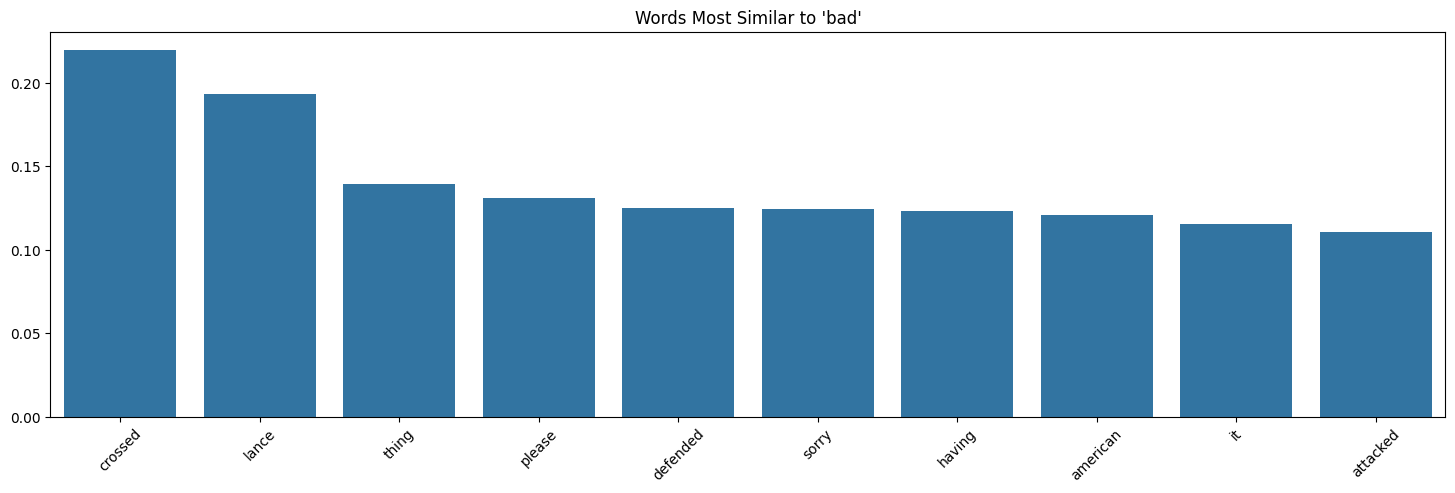

In [50]:
plt.figure(figsize=(18,5))

sns.barplot(x=words, y=scores)
plt.tick_params(axis='x', rotation=45)

plt.title(f"Words Most Similar to '{target}'")
plt.show()

---

## Using skip-gram

In [51]:
df.head(6)

,id,text,label,transformed
0,1,i didn't even want to go in there everyhere i ...,angry,"[i, didnt, even, want, to, go, in, there, ever..."
1,2,how can you speak so passionately about someth...,angry,"[how, can, you, speak, so, passionately, about..."
2,3,everything i have ever cared about is gone,sad,"[everything, i, have, ever, cared, about, is, ..."
3,4,i just want be a doctor or anything to help my...,sad,"[i, just, want, be, a, doctor, or, anything, t..."
4,5,i was pushing towards success and my mentor GP...,happy,"[i, was, pushing, towards, success, and, my, m..."
5,6,"dont judge me. i like rainbow, sparkles and un...",happy,"[dont, judge, me, i, like, rainbow, sparkles, ..."


In [52]:
model = Word2Vec(
    sentences=df['transformed'].tolist(),
    sg=1,       # using skip-gram
    window=7,
    min_count=1,
    workers=4
)

print(f"LENGTH OF THE VOCABULARY : {len(model.wv.index_to_key)}")

LENGTH OF THE VOCABULARY : 370


In [53]:
model.wv.most_similar('good')

[('all', 0.30733874440193176),
 ('information', 0.3060570955276489),
 ('piece', 0.2225412279367447),
 ('simple', 0.2219015508890152),
 ('soul', 0.21528680622577667),
 ('would', 0.20923937857151031),
 ('spot', 0.20254217088222504),
 ('century', 0.20241712033748627),
 ('cuban', 0.19745825231075287),
 ('gun', 0.1954195648431778)]